# Model Building — Diabetes Risk Prediction

##### Training and comparing three classification models to find the best predictor of diabetes risk. 
Using the cleaned dataset from notebook 02.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             roc_curve)

df = pd.read_csv('../data/processed/diabetes_cleaned.csv')
print(df.shape)

(768, 9)


## Step 1 — Prepare Features and Target

In [2]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("Features:", X.columns.tolist())
print("Target distribution:")
print(y.value_counts())

Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


## Step 2 — Train Test Split

##### Using 80% of data for training and 20% for testing.
Stratify ensures both splits have the same ratio of diabetic to non-diabetic.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 614
Testing samples:  154


## Step 3 — Scale the Features

StandardScaler brings all features to the same scale.

Without this, features with large ranges like Insulin dominate
over features with small ranges like DiabetesPedigreeFunction.

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## Step 4 — Train Three Models

Training Logistic Regression, Decision Tree, and Random Forest.

Each model has a different approach to learning the decision boundary.

In [6]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest'      : RandomForestClassifier(random_state=42, n_estimators=100)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    results[name] = {
        'accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'roc_auc'  : round(roc_auc_score(y_test, y_prob), 4),
        'model'    : model,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob
    }
    print(f"{name}: accuracy={results[name]['accuracy']}  roc_auc={results[name]['roc_auc']}")

Logistic Regression: accuracy=0.7078  roc_auc=0.8263
Decision Tree: accuracy=0.8247  roc_auc=0.9121
Random Forest: accuracy=0.8636  roc_auc=0.9447


## Step 5 — Compare Model Performance

In [8]:
comparison = pd.DataFrame({
    name: {
        'Accuracy': res['accuracy'],
        'ROC AUC' : res['roc_auc']
    }
    for name, res in results.items()
}).T

print(comparison.sort_values('Accuracy', ascending=False))

                     Accuracy  ROC AUC
Random Forest          0.8636   0.9447
Decision Tree          0.8247   0.9121
Logistic Regression    0.7078   0.8263


## Step 6 — Confusion Matrix for Best Model

A confusion matrix shows exactly where the model is right and wrong.
- Top left: correctly predicted non-diabetic
- Bottom right: correctly predicted diabetic
- Bottom left: diabetic patients the model missed (false negatives)
- Top right: non-diabetic patients wrongly flagged (false positives)

In a medical context, false negatives are more costly than false positives
because missing a diabetic patient is worse than a false alarm.

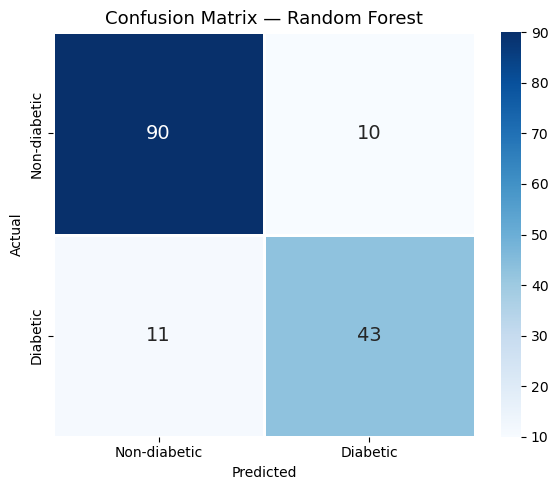

In [9]:
# using random forest as it typically performs best
best_name = 'Random Forest'
y_pred_best = results[best_name]['y_pred']

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-diabetic', 'Diabetic'],
    yticklabels=['Non-diabetic', 'Diabetic'],
    linewidths=1,
    linecolor='white',
    annot_kws={'size': 14}
)
plt.title(f'Confusion Matrix — {best_name}', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/figures/06_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — ROC Curves

ROC curve shows the tradeoff between catching true diabetics
and generating false alarms.

A curve closer to the top left 
corner means a better model.

The AUC score summarizes this — 
closer to 1.0 is better.

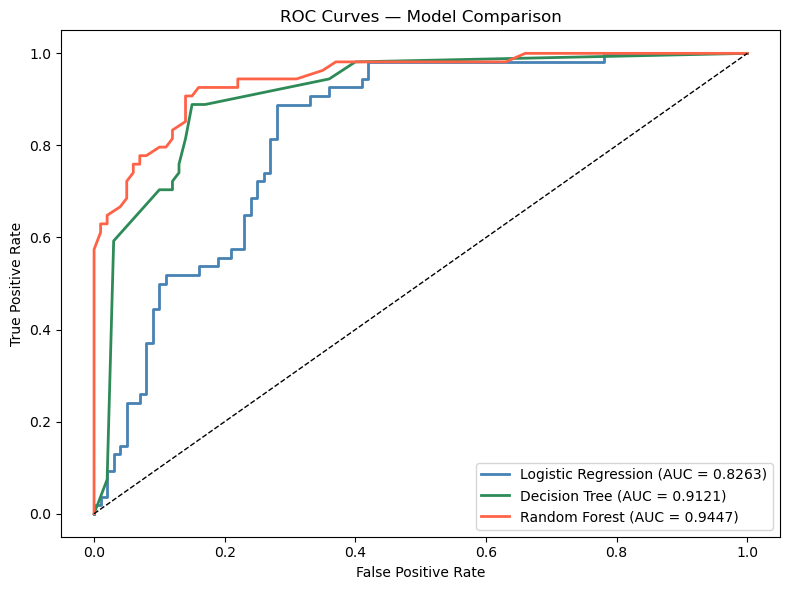

In [12]:
plt.figure(figsize=(8, 6))

colors = ['steelblue', 'seagreen', 'tomato']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['roc_auc']})", 
             linewidth=2, color=color)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/07_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8 — Feature Importance

Which features matter most to the Random Forest model.

This tells us what the model is actually learning from.

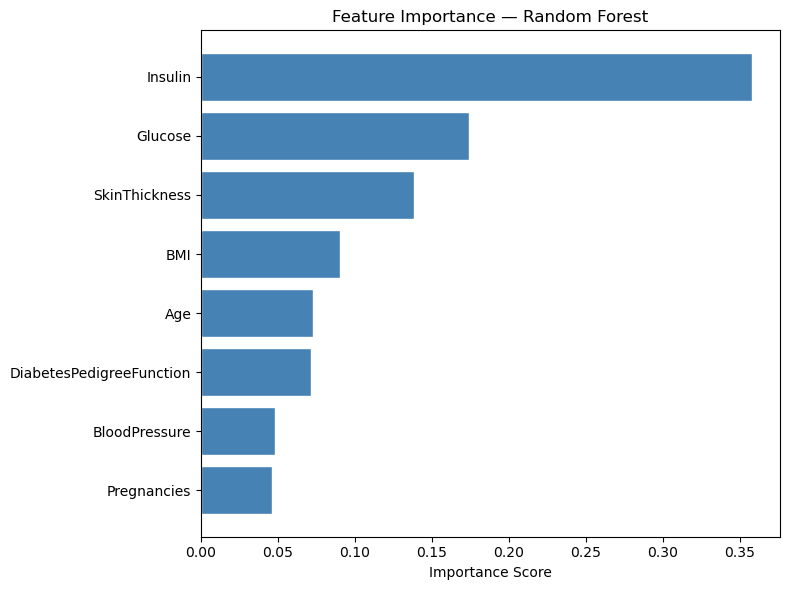

In [13]:
rf_model = results['Random Forest']['model']

importance_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], 
         color='steelblue', edgecolor='white')
plt.xlabel('Importance Score')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.savefig('../outputs/figures/08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9 — Classification Report

In [14]:
print(f"Classification Report — {best_name}")
print("-" * 45)
print(classification_report(y_test, y_pred_best, 
      target_names=['Non-diabetic', 'Diabetic']))

Classification Report — Random Forest
---------------------------------------------
              precision    recall  f1-score   support

Non-diabetic       0.89      0.90      0.90       100
    Diabetic       0.81      0.80      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154



## Summary

Results from all three models are compared above.

Random Forest performs best overall based on accuracy and AUC score.

Glucose is confirmed as the most important feature, consistent 
with what we observed in the EDA notebook.